In [1]:
import sys
sys.path.append('../')

import json
import numpy as np
from rdkit import Chem
from src.tacogfn.utils import molecules
from src.tacogfn.utils import dimension_reduction
from src.tacogfn.utils.unidock import unidock_scores

In [2]:
res1 = json.load(open('../misc/evaluations/0_100_zinc-mo-256-pocket-graph-39000-3_evaluated.json'))
res2 = json.load(open('../misc/evaluations/0_100_zinc-mo-256-no-pharmaco-1_evaluated.json'))

In [3]:
pdb_id_to_avg_score1 = {}
for k, v in res1.items():
    pdb_id_to_avg_score1[k] = np.mean(v['docking_scores'])
    
pdb_id_to_avg_score2 = {}
for k, v in res2.items():
    pdb_id_to_avg_score2[k] = np.mean(v['docking_scores'])

In [12]:
pdb_id_to_avg_score1['3pnm_A'],pdb_id_to_avg_score2['3pnm_A']

(-7.204000000000001, -6.845)

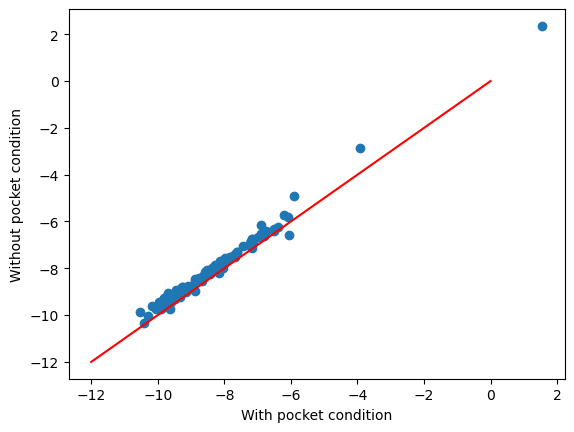

In [4]:
import matplotlib.pyplot as plt

plt.scatter(list(pdb_id_to_avg_score1.values()), list(pdb_id_to_avg_score2.values()))
plt.xlabel('With pocket condition')
plt.ylabel('Without pocket condition')
# x = y line
plt.plot([-12, 0], [-12, 0], color='red')

In [5]:
import matplotlib.pyplot as plt
from typing import List

def plot_principal_components(X_r: np.array, labels: List[float], label_name: str):
    """
    Plot the first two principal components with specified labels as color.

    Parameters:
    - X_r: Data with reduced dimensions (usually from PCA or similar methods)
    - labels: Dictionary containing label data
    - label_type: Type of label to use for coloring (e.g., LabelType.QED)

    Returns:
    - None
    """
    plt.scatter(X_r[:, 0], X_r[:, 1], c=labels, cmap='viridis', alpha=0.25)
    plt.colorbar().set_label(label_name)
    plt.show()

In [8]:
pdb_id_to_avg_score = {}
for k, v in res1.items():
    if v['native_docking_score']:
        pdb_id_to_avg_score[k] = v['native_docking_score']

In [10]:
sorted(pdb_id_to_avg_score.items(), key=lambda x: x[1])

[('4tos_A', -14.98382),
 ('3o96_A', -13.94111),
 ('4ja8_B', -12.89088),
 ('5aeh_A', -11.46841),
 ('1h36_A', -11.00881),
 ('2azy_A', -9.94082),
 ('5q0k_A', -9.64692),
 ('1coy_A', -9.33944),
 ('3hy9_B', -9.10336),
 ('3daf_A', -9.08804),
 ('4azf_A', -8.94342),
 ('3u5y_B', -8.597),
 ('1r1h_A', -8.58685),
 ('1fmc_B', -8.5817),
 ('4xli_B', -8.58093),
 ('2v3r_A', -8.5689),
 ('2z3h_A', -8.50828),
 ('4qlk_A', -8.26639),
 ('1afs_A', -8.26544),
 ('1e8h_A', -8.24805),
 ('4m7t_A', -8.05966),
 ('5liu_X', -7.76126),
 ('1l3l_A', -7.67325),
 ('4h3c_A', -7.6599),
 ('4rlu_A', -7.6482),
 ('4iwq_A', -7.60363),
 ('1phk_A', -7.5869),
 ('1umd_B', -7.4698),
 ('3pdh_A', -7.42209),
 ('4aaw_A', -7.2068),
 ('2f2c_B', -6.956),
 ('3kc1_A', -6.76061),
 ('3nfb_A', -6.69544),
 ('3g51_A', -6.64356),
 ('5bur_A', -6.63397),
 ('2rma_A', -6.58764),
 ('4pxz_A', -6.54801),
 ('1ai4_A', -6.53918),
 ('3tym_A', -6.53666),
 ('2hcj_B', -6.51222),
 ('4iiy_A', -6.49828),
 ('5l1v_A', -6.48118),
 ('4d7o_A', -6.37719),
 ('3u9f_C', -6.08

In [7]:
sorted_pdb_id_to_avg_score = sorted(pdb_id_to_avg_score1.items(), key=lambda x: x[1])

In [8]:
ranka = 5
rankb = -1

pdb_a  = sorted_pdb_id_to_avg_score[ranka][0]
pdb_b  = sorted_pdb_id_to_avg_score[rankb][0]

sorted_pdb_id_to_avg_score[ranka], sorted_pdb_id_to_avg_score[rankb]

(('4z2g_A', -9.985), ('4p6p_A', 1.5470000000000002))

Exception ignored on calling ctypes callback function: <function _ThreadpoolInfo._find_modules_with_dl_iterate_phdr.<locals>.match_module_callback at 0x7f76ad68caf0>
Traceback (most recent call last):
  File "/home/tsa87/anaconda3/envs/tacogfn/lib/python3.9/site-packages/threadpoolctl.py", line 400, in match_module_callback
    self._make_module_from_path(filepath)
  File "/home/tsa87/anaconda3/envs/tacogfn/lib/python3.9/site-packages/threadpoolctl.py", line 515, in _make_module_from_path
    module = module_class(filepath, prefix, user_api, internal_api)
  File "/home/tsa87/anaconda3/envs/tacogfn/lib/python3.9/site-packages/threadpoolctl.py", line 606, in __init__
    self.version = self.get_version()
  File "/home/tsa87/anaconda3/envs/tacogfn/lib/python3.9/site-packages/threadpoolctl.py", line 646, in get_version
    config = get_config().split()
AttributeError: 'NoneType' object has no attribute 'split'


0.4476139126814333
0.4603184833960707
4z2g_A mean: 383.71791000000013 std: 17.022634648664138
4p6p_A mean: 385.5777200000001 std: 13.266899319795883


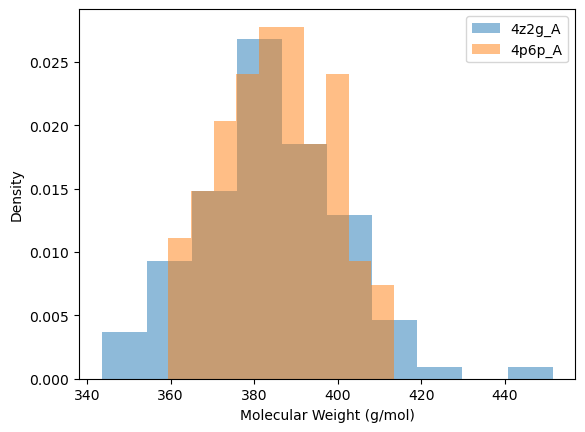

In [9]:
res = res1

molA = [Chem.MolFromSmiles(s) for s in res[pdb_a]['smiles']]
molB = [Chem.MolFromSmiles(s) for s in res[pdb_b]['smiles']]

molA_wts = molecules.get_wt_from_smiles(res[pdb_a]['smiles'])[0]
molB_wts = molecules.get_wt_from_smiles(res[pdb_b]['smiles'])[0]

features = [Chem.RDKFingerprint(mol) for mol in molA + molB]
features = np.array([np.array(f) for f in features])

pca_r =  dimension_reduction.reduce_dimensions(features,  dimension_reduction.DimensionReductionType.PCA)
tsne_r =  dimension_reduction.reduce_dimensions(features,  dimension_reduction.DimensionReductionType.TSNE)

print(np.mean(molecules.compute_diversity(molB)))
print(np.mean(molecules.compute_diversity_two_sets(molA, molB)))

molecules.plot_histogram(molA_wts, molB_wts, pdb_a, pdb_b)

In [10]:
import torch 
rec_folder = "../dataset/crossdocktest_pdbqt"
pocket_to_centroid_path = "../dataset/pocket_to_centroid.pt"
pocket_to_centroid = torch.load(pocket_to_centroid_path)
pocket_to_centroid['4p6p_A']

/home/tsa87/anaconda3/envs/tacogfn/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(-8.671571428571427, 3.8687142857142853, -30.18764285714286)

In [11]:
import os
unidock_scores(res[pdb_b]['smiles'], os.path.join(rec_folder, '4p6p_A_rec.pdbqt'), -8.671571428571427, 3.8687142857142853, -30.18764285714286, out_folder='with_pocket')

Using output folder: with_pocket


Processing SMILES: 100%|██████████| 100/100 [00:00<00:00, 456.60it/s]
/home/tsa87/anaconda3/envs/tacogfn/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


[INFO][2024-06-29 16:20:04,257][main.py 28] [Params] {'cmd': 'unidock_pipeline', 'receptor': '../dataset/crossdocktest_pdbqt/4p6p_A_rec.pdbqt', 'ligands': None, 'ligand_index': 'with_pocket/smiles_list.txt', 'center_x': -8.671571428571427, 'center_y': 3.8687142857142853, 'center_z': -30.18764285714286, 'size_x': 22.5, 'size_y': 22.5, 'size_z': 22.5, 'workdir': 'unidock_pipeline_oihah', 'savedir': 'with_pocket/docking', 'batch_size': 18000, 'scoring_function': 'vina', 'search_mode': '', 'exhaustiveness': 128, 'max_step': 20, 'num_modes': 3, 'refine_step': 3, 'energy_range': 3.0, 'topn': 100, 'score_only': False, 'local_only': False, 'seed': 181129, 'debug': False}
[INFO][2024-06-29 16:20:04,261][unidock_pipeline.py 223] [UniDock Pipeline] 100 ligands found.
[INFO][2024-06-29 16:20:04,261][unidock_pipeline.py 225] [UniDock Pipeline] Start
[INFO][2024-06-29 16:20:04,295][unidock_pipeline.py 238] [UniDock Pipeline] Start docking
[INFO][2024-06-29 16:20:05,125][unidock.py 94] unidock cmd: u

[-5.062,
 -4.406,
 -4.41,
 -4.666,
 -4.595,
 0.357,
 -5.197,
 -4.677,
 -2.067,
 -2.441,
 -3.075,
 -3.695,
 -4.281,
 -3.605,
 -4.332,
 -4.088,
 -3.618,
 -1.107,
 -2.748,
 -3.945,
 -2.9,
 4.358,
 -4.869,
 0.486,
 -3.333,
 -2.282,
 0.145,
 -3.161,
 -3.287,
 -4.457,
 -4.151,
 -2.102,
 -1.493,
 -4.161,
 -4.122,
 -4.797,
 -1.768,
 4.181,
 -4.093,
 -4.894,
 -4.796,
 -4.408,
 -4.027,
 -4.381,
 -2.219,
 -5.096,
 -3.357,
 -4.143,
 1.209,
 -3.124,
 -4.587,
 -3.253,
 -4.742,
 -4.662,
 -2.353,
 -4.376,
 -4.533,
 -4.041,
 -2.698,
 -4.575,
 -2.595,
 -3.12,
 1.235,
 -2.497,
 -2.56,
 -4.294,
 -1.514,
 -5.244,
 -1.316,
 -4.498,
 3.622,
 -2.789,
 1.389,
 -4.374,
 -3.952,
 -0.339,
 -3.951,
 -4.239,
 -3.692,
 -4.741,
 -0.676,
 -4.819,
 -4.885,
 -2.613,
 -4.877,
 -2.302,
 -4.077,
 -0.85,
 1.56,
 -2.608,
 6.416,
 -3.069,
 0.447,
 -2.802,
 2.443,
 -2.654,
 -2.324,
 3.384,
 -5.227,
 -4.36]

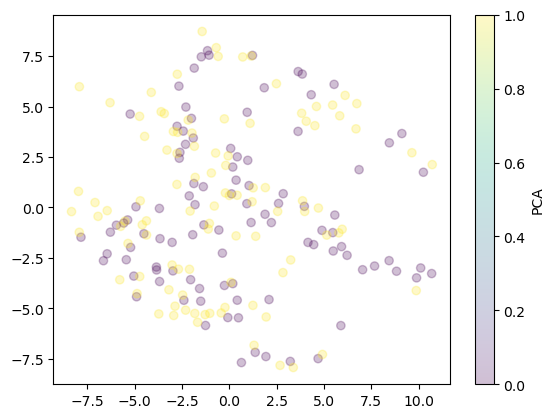

In [12]:
plot_principal_components(pca_r, np.array([0]*len(molA) + [1]*len(molB)), 'PCA')

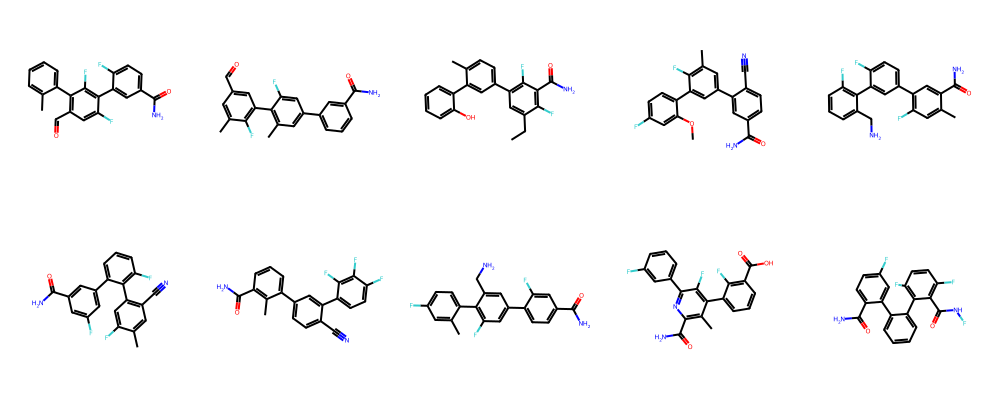

In [13]:
from rdkit.Chem import Draw

Draw.MolsToGridImage(molB[:10], molsPerRow=5)

0.5015860361995725
0.5044178209344231
4z2g_A mean: 380.84670000000006 std: 24.146878646524925
4p6p_A mean: 379.4009300000001 std: 22.907493546983734


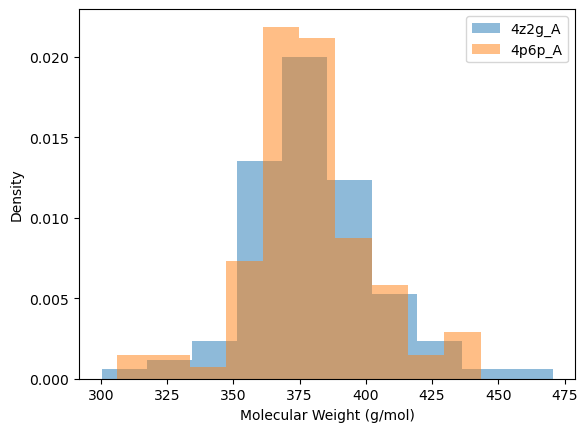

In [14]:
res = res2

molA = [Chem.MolFromSmiles(s) for s in res[pdb_a]['smiles']]
molB = [Chem.MolFromSmiles(s) for s in res[pdb_b]['smiles']]
molA_wts = molecules.get_wt_from_smiles(res[pdb_a]['smiles'])[0]
molB_wts = molecules.get_wt_from_smiles(res[pdb_b]['smiles'])[0]

print(np.mean(molecules.compute_diversity(molB)))
print(np.mean(molecules.compute_diversity_two_sets(molA, molB)))

molecules.plot_histogram(molA_wts, molB_wts, pdb_a, pdb_b)

In [21]:
import os
unidock_scores(res2[pdb_b]['smiles'], os.path.join(rec_folder, '4p6p_A_rec.pdbqt'), -8.671571428571427, 3.8687142857142853, -30.18764285714286, out_folder='no_pocket')

Using output folder: no_pocket


Processing SMILES: 100%|██████████| 100/100 [00:00<00:00, 379.55it/s]
/home/tsa87/anaconda3/envs/tacogfn/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


[INFO][2024-06-29 16:20:39,997][main.py 28] [Params] {'cmd': 'unidock_pipeline', 'receptor': '../dataset/crossdocktest_pdbqt/4p6p_A_rec.pdbqt', 'ligands': None, 'ligand_index': 'no_pocket/smiles_list.txt', 'center_x': -8.671571428571427, 'center_y': 3.8687142857142853, 'center_z': -30.18764285714286, 'size_x': 22.5, 'size_y': 22.5, 'size_z': 22.5, 'workdir': 'unidock_pipeline_zforo', 'savedir': 'no_pocket/docking', 'batch_size': 18000, 'scoring_function': 'vina', 'search_mode': '', 'exhaustiveness': 128, 'max_step': 20, 'num_modes': 3, 'refine_step': 3, 'energy_range': 3.0, 'topn': 100, 'score_only': False, 'local_only': False, 'seed': 181129, 'debug': False}
[INFO][2024-06-29 16:20:39,999][unidock_pipeline.py 223] [UniDock Pipeline] 100 ligands found.
[INFO][2024-06-29 16:20:39,999][unidock_pipeline.py 225] [UniDock Pipeline] Start
[INFO][2024-06-29 16:20:40,033][unidock_pipeline.py 238] [UniDock Pipeline] Start docking
[INFO][2024-06-29 16:20:40,825][unidock.py 94] unidock cmd: unido

[-4.649,
 -3.833,
 -3.764,
 -3.811,
 -4.217,
 -4.905,
 -4.281,
 -5.14,
 -3.741,
 -4.715,
 -3.358,
 -3.442,
 -4.22,
 -3.4,
 -4.28,
 -2.833,
 -3.913,
 -5.492,
 -4.299,
 -3.871,
 -0.688,
 -4.842,
 2.844,
 -4.857,
 -3.806,
 -3.938,
 -4.07,
 -5.223,
 -4.335,
 -4.655,
 -3.995,
 -4.222,
 -4.305,
 -4.465,
 -2.88,
 -1.298,
 -4.68,
 -4.964,
 -3.904,
 -3.854,
 -3.667,
 -3.037,
 -2.361,
 -3.943,
 -3.589,
 -2.298,
 -4.847,
 -3.095,
 -2.123,
 -3.491,
 -4.598,
 -2.887,
 -2.807,
 4.02,
 -3.02,
 -5.263,
 -3.834,
 0.592,
 -3.961,
 -3.21,
 -4.04,
 7.046,
 -1.533,
 -4.613,
 -0.461,
 -4.389,
 3.748,
 -0.515,
 -4.303,
 -4.589,
 -3.285,
 -3.595,
 1.144,
 -0.501,
 -1.935,
 -4.916,
 -4.287,
 -3.672,
 -4.536,
 -3.508,
 -3.862,
 -2.193,
 5.589,
 -4.621,
 -3.728,
 -3.908,
 -3.726,
 -4.288,
 0.782,
 -2.594,
 1.796,
 -2.56,
 -3.185,
 -3.348,
 0.769,
 -2.305,
 -2.439,
 -2.805,
 -4.388,
 -4.844]

In [16]:
# Intrapocket diversity
np.mean(molecules.compute_diversity(molA))

0.509319422947406

In [17]:
np.mean(molecules.compute_diversity(molB))

0.5015860361995725

In [18]:
np.mean(molecules.compute_diversity_two_sets(molA, molB))

0.5044178209344231

In [19]:
# smiles = []
# intra_diversity = []

# for _, r in res.items():
#     smiles.extend(r['smiles'])
#     intra_diversity.append(molecules.compute_diversity([Chem.MolFromSmiles(s) for s in r['smiles']]))
    
# print('Intra-diversity:', np.mean(intra_diversity))

In [20]:
mols = [Chem.MolFromSmiles(s) for s in smiles]
inter_diversity = molecules.compute_diversity(mols)

NameError: name 'smiles' is not defined

In [ ]:
np.mean(inter_diversity)

0.4374074719161902

In [ ]:
from glob import glob
from src.tacogfn.utils.molecules import sdf_to_single_smiles

In [ ]:
sdf_files = glob('../dataset/crossdock/*lig.sdf')

In [ ]:
ligands = set()

for f in sdf_files:
    ligands.add(sdf_to_single_smiles(f))

In [ ]:
mols = [Chem.MolFromSmiles(s) for s in ligands if s is not None]
mols = [m for m in mols if m is not None]
np.mean(molecules.compute_diversity(mols))

0.7629261342128825